In [8]:
#Para PCA
import numpy as np
import pandas as pd
import prince
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

#Para clustering

from sklearn.cluster import KMeans, HDBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score, silhouette_samples
)


## Descargamos base de datos

In [9]:
excel_path = Path.cwd().parent / "Ejercicio_1_datos_y_etiquetas.xlsx"
df = pd.read_excel(excel_path, sheet_name="Datos")

In [10]:
diccionario_df = pd.read_excel(
   excel_path,
    sheet_name="Diccionario"
)
diccionario_df

,Variable,Descripción
0,firm_id,Identificador único de la empresa. Tratar como...
1,firm_name,Nombre ficticio de la empresa. Tratar como ide...
2,sector,Sector económico simulado.
3,reporting_period,Período común de análisis. Es constante en tod...
4,revenue_reported_mm,"Ingresos reportados, en millones."
5,revenue_growth_pct,Crecimiento de ingresos respecto del período p...
6,operating_expenses_reported_mm,"Gastos operativos reportados, en millones."
7,ebitda_reported_mm,"EBITDA reportado, en millones."
8,ebitda_margin_change_pp,Cambio del margen EBITDA respecto del período ...
9,cfo_reported_mm,"Flujo de caja operativo reportado, en millones."


## Feature engineering y selección de variables

In [11]:
# FAMD/PCAmix recibe el sector como una única variable categórica
sector = df['sector'].astype('category')
df['interest/EBITDA']= df['interest_expense_reported_mm']/df['ebitda_reported_mm']
df['ebitda_adjustment_pct'] = ((df['adjusted_ebitda_reported_mm'] - df['ebitda_reported_mm'])/ df['ebitda_reported_mm'].abs()
)

In [12]:
df.columns

Index(['firm_id', 'firm_name', 'sector', 'reporting_period',
       'revenue_reported_mm', 'revenue_growth_pct',
       'operating_expenses_reported_mm', 'ebitda_reported_mm',
       'ebitda_margin_change_pp', 'cfo_reported_mm', 'capex_total_reported_mm',
       'capex_growth_pct', 'maintenance_capex_reported_mm',
       'growth_capex_reported_mm', 'adjusted_ebitda_reported_mm',
       'interest_expense_reported_mm', 'cash_taxes_reported_mm',
       'net_income_reported_mm', 'dividends_mm', 'debt_avg_mm',
       'debt_end_reported_mm', 'total_assets_reported_mm', 'cash_reported_mm',
       'accounts_receivable_reported_mm', 'inventory_reported_mm',
       'npl_reported_mm', 'npl_growth_pct', 'provision_reported_mm',
       'loan_loss_reserve_reported_mm', 'coverage_change_pp',
       'ebitda_margin_pct', 'cfo_margin_pct', 'capex_intensity_pct',
       'maintenance_capex_share_pct', 'fcf_reported_mm',
       'distributable_cash_flow_reported_mm', 'dcf_fcf_gap_mm',
       'dividend_cover

In [13]:
features_excluidas = [
    'firm_id', # irrelevante
    'firm_name', # irrelevante
    'reporting_period', # irrelevante
    'sector', # se incorpora por separado como variable categórica
    
    'dividend_coverage_dcf_x', #No se encuentran definidos para las empresas que no distribuyeron dividendos
    'dividend_coverage_fcf_x',#No se encuentran definidos para las empresas que no distribuyeron dividendos
    
    'npl_growth_pct',  # solo financials
     'coverage_change_pp',# solo financials
      'credit_loss_coverage_reported_x',# solo financials
      'provision_reported_mm', #solo financials
      'loan_loss_reserve_reported_mm', #solo financials
      'npl_reported_mm', #solo financials

     #'cfo_margin_pct', #correlacionada con ebitda_margin_pct ### OJO QUE VALEN LA USA
      'leverage_reported_x',  # correlacionada con las otras dos anteriores
    'operating_expenses_reported_mm', #se obtiene exactamente de ingresos menos EBITDA
    'fcf_reported_mm', # es CFO menos capex
    'leverage_avg_x', # muy similar a leverage_reported_x
    'adjusted_ebitda_reported_mm', # dejamos ebitda_adjustment_mm que creamos
   'maintenance_capex_reported_mm', # redundante con las otras
'growth_capex_reported_mm', #maintenance_capex_reported_mm + growth_capex_reported_mm
'distributable_cash_flow_reported_mm', #distributable_cash_flow_reported_mm = ( dcf_fcf_gap_mm + cfo_reported_mm- capex_total_reported_mm)
]

features = [columna for columna in df.columns if columna not in features_excluidas
]

In [14]:
def aplicar_log_a_montos(df):
    ## Funcion para que quede en logaritmos, pero con signo correcto

    df_transformado = df.copy()

#Busco las columnas con mm al final
    columnas_mm = [
        columna
        for columna in df_transformado.columns
        if columna.endswith("_mm")
    ]

    for columna in columnas_mm:
        valores = df_transformado[columna]

        df_transformado[columna] = (
            np.sign(valores) * np.log1p(valores.abs())
        )

    return df_transformado, columnas_mm

df_feat = df[features].copy()

df_feat, variables_transformadas = aplicar_log_a_montos(df_feat)


In [15]:
len(features)

27

In [16]:
df_feat

,revenue_reported_mm,revenue_growth_pct,ebitda_reported_mm,ebitda_margin_change_pp,cfo_reported_mm,capex_total_reported_mm,capex_growth_pct,interest_expense_reported_mm,cash_taxes_reported_mm,net_income_reported_mm,...,ebitda_margin_pct,cfo_margin_pct,capex_intensity_pct,maintenance_capex_share_pct,dcf_fcf_gap_mm,debt_end_to_avg_x,cfo_to_ebitda_reported_x,assets_to_revenue_x,interest/EBITDA,ebitda_adjustment_pct
0,6.111704,0.096128,4.590004,0.000401,4.282464,3.394660,-0.114508,2.839440,2.545292,4.118428,...,0.216604,0.158670,0.063995,0.615215,2.349602,1.038741,0.732538,1.797173,0.165200,0.001793
1,5.257515,-0.008027,4.081896,0.008613,3.669964,2.763736,0.122418,2.041534,2.199882,3.717206,...,0.305008,0.200260,0.077794,0.466546,2.756735,0.955541,0.656574,0.936620,0.115048,0.026450
2,5.364020,-0.039645,4.097081,0.012086,3.899715,3.910066,-0.013380,2.711087,1.948401,3.306631,...,0.278314,0.227622,0.230040,0.575685,2.628019,0.968734,0.817863,2.317827,0.237400,0.023381
3,5.336399,0.012685,4.223461,0.002958,3.698329,2.096663,0.034519,2.136565,2.718253,3.754402,...,0.325345,0.190458,0.034527,0.556576,2.549108,0.959788,0.585404,4.396203,0.111050,0.035152
4,4.581225,0.041338,3.225030,0.002733,3.052703,2.991525,0.160860,1.256321,1.426441,2.626270,...,0.249957,0.208752,0.195749,0.671471,1.757993,0.899404,0.835151,2.626447,0.104018,0.011626
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,5.123437,0.041387,3.871392,-0.001184,3.642954,1.573352,-0.023768,2.327891,2.112380,3.361442,...,0.281641,0.222900,0.022903,0.625488,-1.562901,0.992676,0.791431,4.342179,0.196904,0.032232
996,5.769083,0.052539,4.556643,-0.012830,4.174814,1.918488,0.119097,3.399484,2.278010,3.918572,...,0.295270,0.200560,0.018201,0.563348,0.510456,0.945796,0.679244,5.909210,0.307104,0.059400
997,5.218119,0.001782,3.822496,0.009932,3.220470,3.399183,0.028764,1.994118,1.971756,3.230632,...,0.243581,0.130946,0.157635,0.710283,2.929919,1.039831,0.537586,2.303446,0.141905,0.026667
998,5.754344,0.032675,4.665565,0.009169,4.151065,4.484383,0.080504,2.840659,2.510900,4.061604,...,0.334518,0.198696,0.278556,0.783400,3.628893,0.989253,0.593977,2.446862,0.153262,0.022915


In [17]:
features

['revenue_reported_mm',
 'revenue_growth_pct',
 'ebitda_reported_mm',
 'ebitda_margin_change_pp',
 'cfo_reported_mm',
 'capex_total_reported_mm',
 'capex_growth_pct',
 'interest_expense_reported_mm',
 'cash_taxes_reported_mm',
 'net_income_reported_mm',
 'dividends_mm',
 'debt_avg_mm',
 'debt_end_reported_mm',
 'total_assets_reported_mm',
 'cash_reported_mm',
 'accounts_receivable_reported_mm',
 'inventory_reported_mm',
 'ebitda_margin_pct',
 'cfo_margin_pct',
 'capex_intensity_pct',
 'maintenance_capex_share_pct',
 'dcf_fcf_gap_mm',
 'debt_end_to_avg_x',
 'cfo_to_ebitda_reported_x',
 'assets_to_revenue_x',
 'interest/EBITDA',
 'ebitda_adjustment_pct']

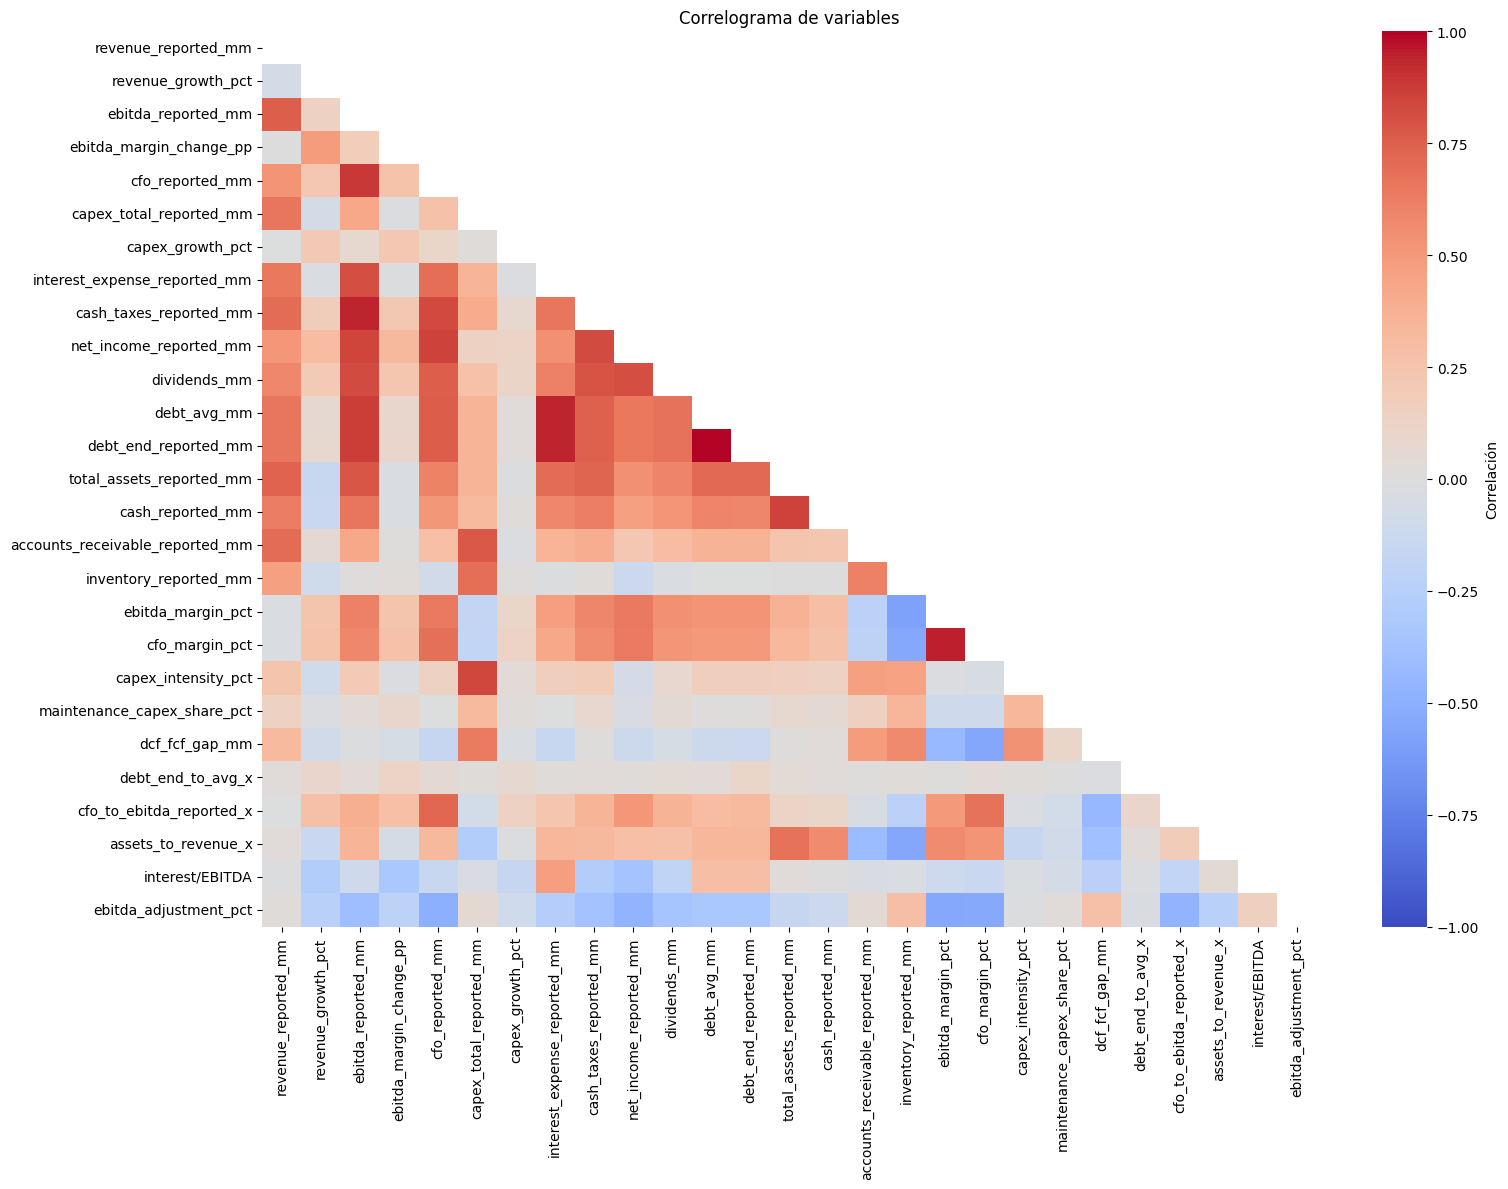

In [18]:
# Correlograma 
corr = df_feat.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr, mask=mask, cmap='coolwarm', center=0,
    vmin=-1, vmax=1, cbar_kws={'label': 'Correlación'}
)
plt.title('Correlograma de variables')
plt.tight_layout()
plt.show()

In [19]:
df_feat.describe()

,revenue_reported_mm,revenue_growth_pct,ebitda_reported_mm,ebitda_margin_change_pp,cfo_reported_mm,capex_total_reported_mm,capex_growth_pct,interest_expense_reported_mm,cash_taxes_reported_mm,net_income_reported_mm,...,ebitda_margin_pct,cfo_margin_pct,capex_intensity_pct,maintenance_capex_share_pct,dcf_fcf_gap_mm,debt_end_to_avg_x,cfo_to_ebitda_reported_x,assets_to_revenue_x,interest/EBITDA,ebitda_adjustment_pct
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,5.372602,0.020862,3.829298,-0.006591,3.361966,2.835601,0.013527,2.340561,1.985862,3.096135,...,0.227843,0.154978,0.097574,0.554795,1.703085,1.004179,0.646870,2.380977,0.223620,0.051259
std,0.510408,0.058333,0.647861,0.015106,0.894957,0.958529,0.091668,0.673606,0.598592,0.807364,...,0.088906,0.076882,0.076490,0.108472,1.734622,0.048958,0.172629,1.388352,0.096025,0.043482
min,3.898923,-0.140520,1.615764,-0.038450,-1.881208,0.783648,-0.189943,0.582712,0.404303,-2.411928,...,0.035000,-0.030808,0.010129,0.126344,-4.300635,0.743142,-0.880238,0.860800,0.055323,0.000015
25%,5.015956,-0.016971,3.396953,-0.018684,2.945481,2.123160,-0.062367,1.853058,1.550725,2.650923,...,0.159226,0.100183,0.039659,0.479734,1.157490,0.968862,0.582133,1.414867,0.148311,0.021627
50%,5.375425,0.022884,3.870143,-0.005516,3.478665,2.735952,0.013863,2.317525,1.986026,3.163560,...,0.218736,0.148648,0.072743,0.558517,2.191946,1.006162,0.674009,1.833931,0.211017,0.042091
75%,5.724063,0.060550,4.256570,0.004918,3.895182,3.541922,0.087796,2.817300,2.389536,3.613749,...,0.293559,0.204463,0.131462,0.633746,2.857130,1.043058,0.747889,2.898040,0.282891,0.068246
max,7.272230,0.163869,6.264883,0.041005,6.043477,5.809825,0.179836,5.252470,4.003660,5.329033,...,0.475518,0.382788,0.355658,0.818160,4.682137,1.079944,0.939526,6.485619,0.550428,0.437463


In [20]:
# Cantidad de valores nulos por variable
nulls_df_feat = df_feat.isna().sum().sort_values(ascending=False)

# Mostrar solamente las variables que tienen al menos un nulo
nulls_df_feat[nulls_df_feat > 0]

Series([], dtype: int64)

## PCA Mix

In [21]:
# Incluimos el sector como variable categorica 
df_mix = df_feat.copy()
df_mix['sector'] = sector

# Dimensión máxima: numéricas + sector - 1 
n_components_famd = len(features) + df_mix['sector'].nunique() - 1
print(f"Cantidad de componentes pca: {n_components_famd}")

famd = prince.FAMD(
    n_components=n_components_famd,
    n_iter=5,
    random_state=42,
    engine='sklearn'
)
X_famd = famd.fit_transform(df_mix)
## Hago que cada columnna tenga nombres como pc1, pc2, etc
X_famd.columns = [f'PC{i+1}' for i in range(X_famd.shape[1])]



Cantidad de componentes pca: 31


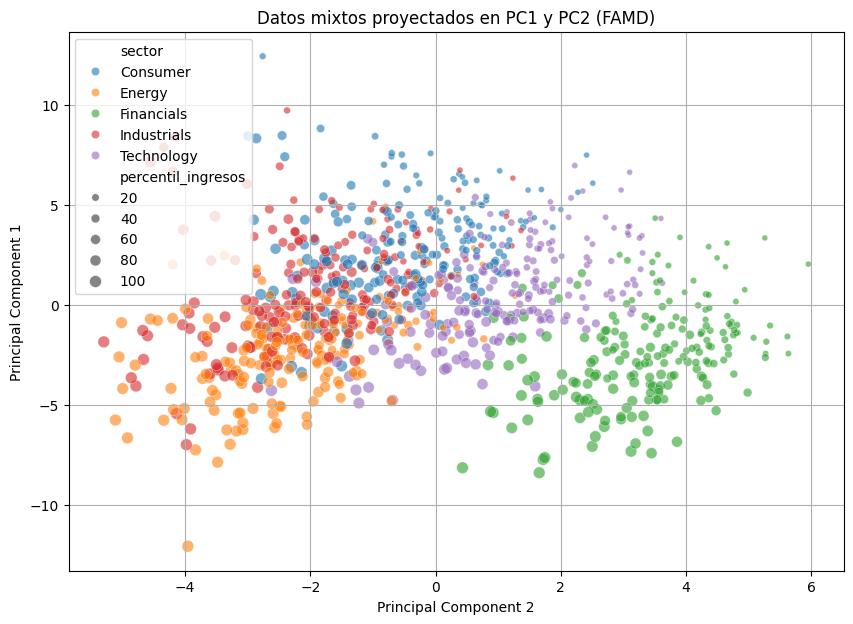

In [22]:
# Versión estandarizada de las numéricas, usando el scaler interno de FAMD
numeric_scaled_df = pd.DataFrame(
    famd.num_scaler_.transform(df_mix[features]),
    columns=features,
    index=df_mix.index
)


# Conservamos el sector para identificar las observaciones en los gráficos
famd_plot = pd.DataFrame({
    'PC1': X_famd['PC1'],
    'PC2': X_famd['PC2'],
    'PC3': X_famd['PC3'],
    'PC4': X_famd['PC4'],
    'sector': sector,
    'revenue_reported_mm': df['revenue_reported_mm'],
})


famd_plot["percentil_ingresos"] = (
    famd_plot["revenue_reported_mm"].rank(pct=True) * 100
)

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=famd_plot,
    x='PC2',
    y='PC1',
    hue='sector',
    alpha=0.6,
    size="percentil_ingresos",
)

plt.xlabel("Principal Component 2")
plt.ylabel("Principal Component 1")
plt.title("Datos mixtos proyectados en PC1 y PC2 (FAMD)")
plt.grid(True)
plt.show()

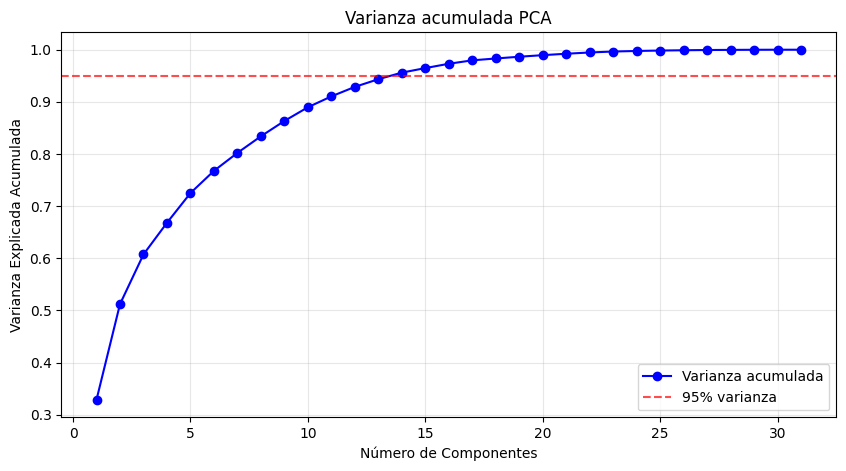

Componentes para 95% varianza: 14


In [23]:

# Prince informa porcentajes; los convertimos a proporciones para mantener los gráficos
explained_variance_ratio = np.asarray(famd.percentage_of_variance_) / 100
cumsum_var = np.cumsum(explained_variance_ratio)
k_95 = np.argmax(cumsum_var >= 0.95) + 1

# Plot
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumsum_var) + 1), cumsum_var, 'bo-', label='Varianza acumulada')
plt.axhline(y=0.95, color='r', linestyle='--', alpha=0.7, label='95% varianza')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('Varianza acumulada PCA')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


print(f"Componentes para 95% varianza: {k_95}")


In [24]:
cumsum_var

array([0.32881192, 0.51206312, 0.60742955, 0.6680965 , 0.72507959,
       0.76767996, 0.80214353, 0.83399741, 0.86335948, 0.88964905,
       0.91050802, 0.92875637, 0.94343123, 0.95605442, 0.9647788 ,
       0.97307235, 0.97963345, 0.98319662, 0.98654922, 0.98957394,
       0.99228009, 0.99470255, 0.99655306, 0.99760686, 0.99842138,
       0.99897997, 0.99943931, 0.99968856, 0.99988259, 0.99999982,
       1.        ])

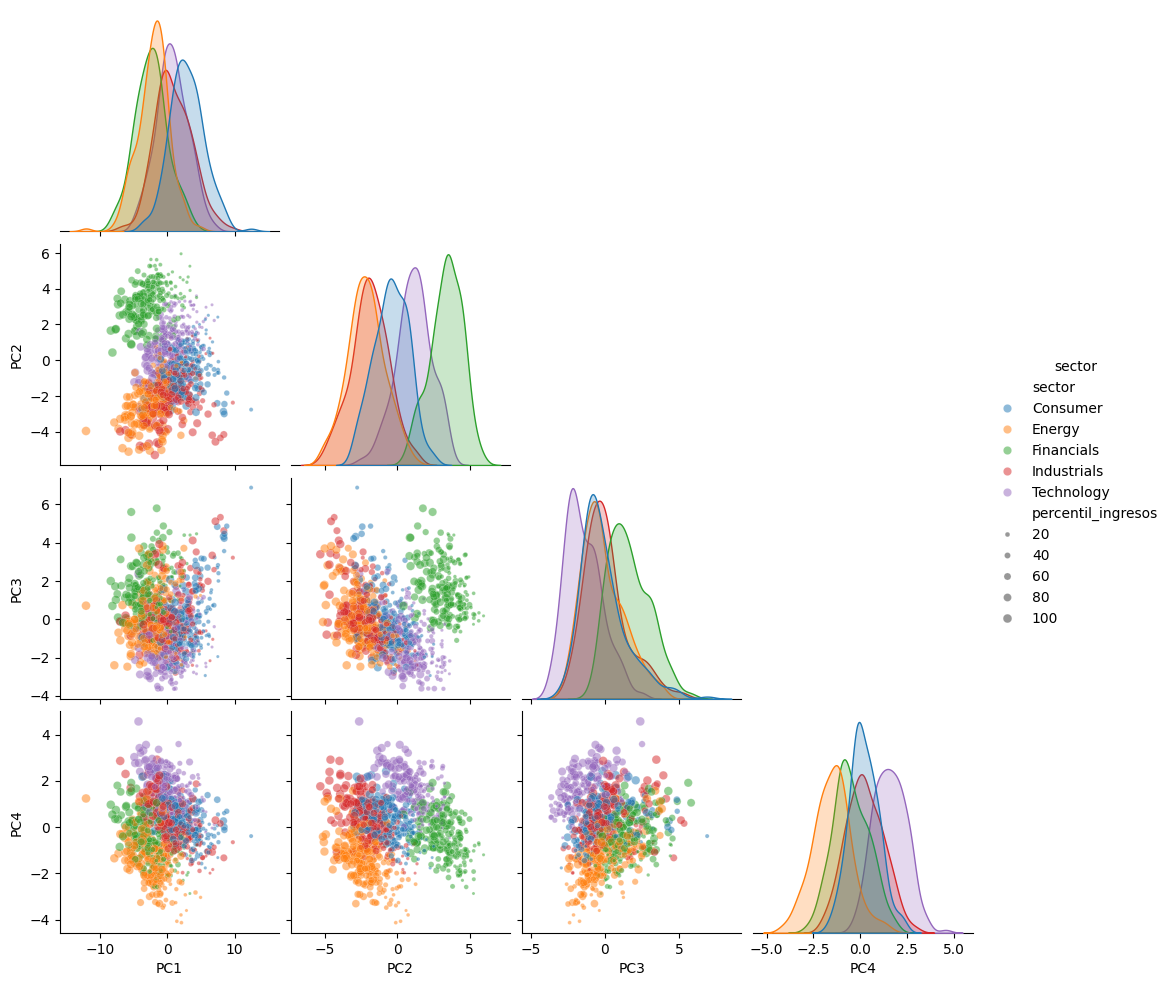

In [25]:
# Para clustering los componentes que explican el 95% de la varianza

famd_df = X_famd.iloc[:, :k_95].copy()

famd_df["sector"] = sector
famd_df["revenue_reported_mm"] = df["revenue_reported_mm"]


famd_df["percentil_ingresos"] = (famd_df["revenue_reported_mm"].rank(pct=True) * 100)


# Dejamos solo 6 componentes en el grafico
pairplot_components = [f'PC{i}' for i in range(1, 5)]

sns.pairplot(
    famd_df[pairplot_components + ['sector']],
    hue="sector",
    corner=True,
       plot_kws={
        "alpha": 0.50,
        "size": famd_df["percentil_ingresos"],
        "sizes": (5, 40)
    }
)

plt.show()

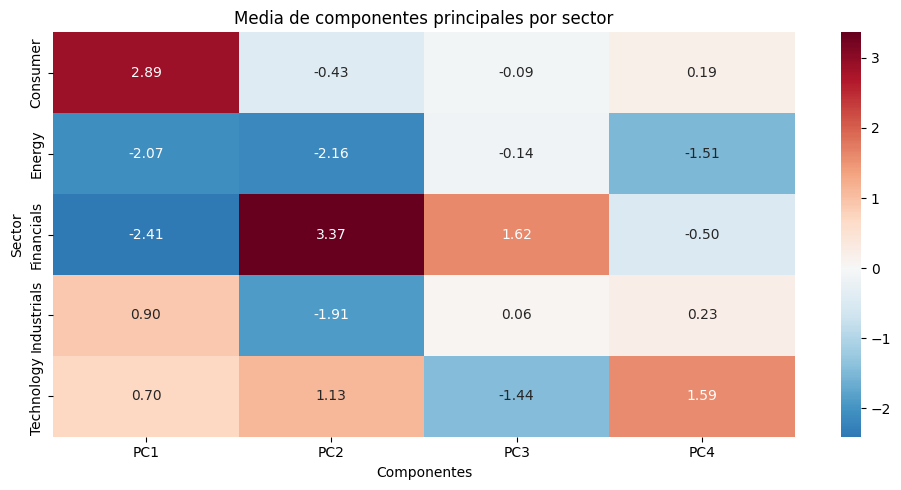

In [26]:
scores_sector = X_famd.loc[:, pairplot_components].copy()

scores_sector["sector"] = sector.values

# Promedio de cada componente por sector
media_sector = scores_sector.groupby("sector" , observed=True).mean()


plt.figure(figsize=(10, 5))

sns.heatmap(
    media_sector,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,

)

plt.title("Media de componentes principales por sector")
plt.xlabel("Componentes")
plt.ylabel("Sector")
plt.tight_layout()
plt.show()

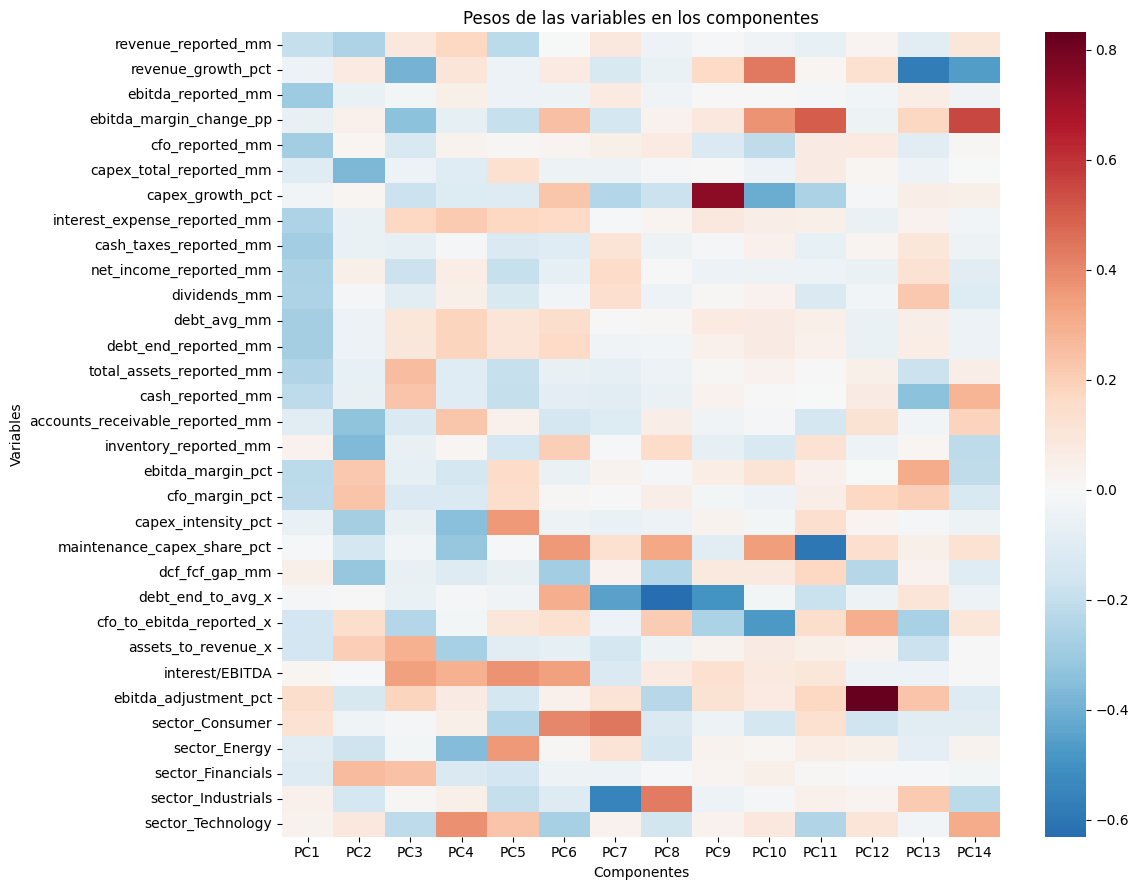

In [27]:
# Pesos de cada variable en los componentes
pesos = pd.DataFrame(
    famd.svd_.V.T,
    index=famd.feature_names_in_,
    columns=[f'PC{i+1}' for i in range(famd.svd_.V.shape[0])]
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    pesos.iloc[:, :k_95],
    cmap='RdBu_r',
    center=0
)

plt.title('Pesos de las variables en los componentes')
plt.xlabel('Componentes')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

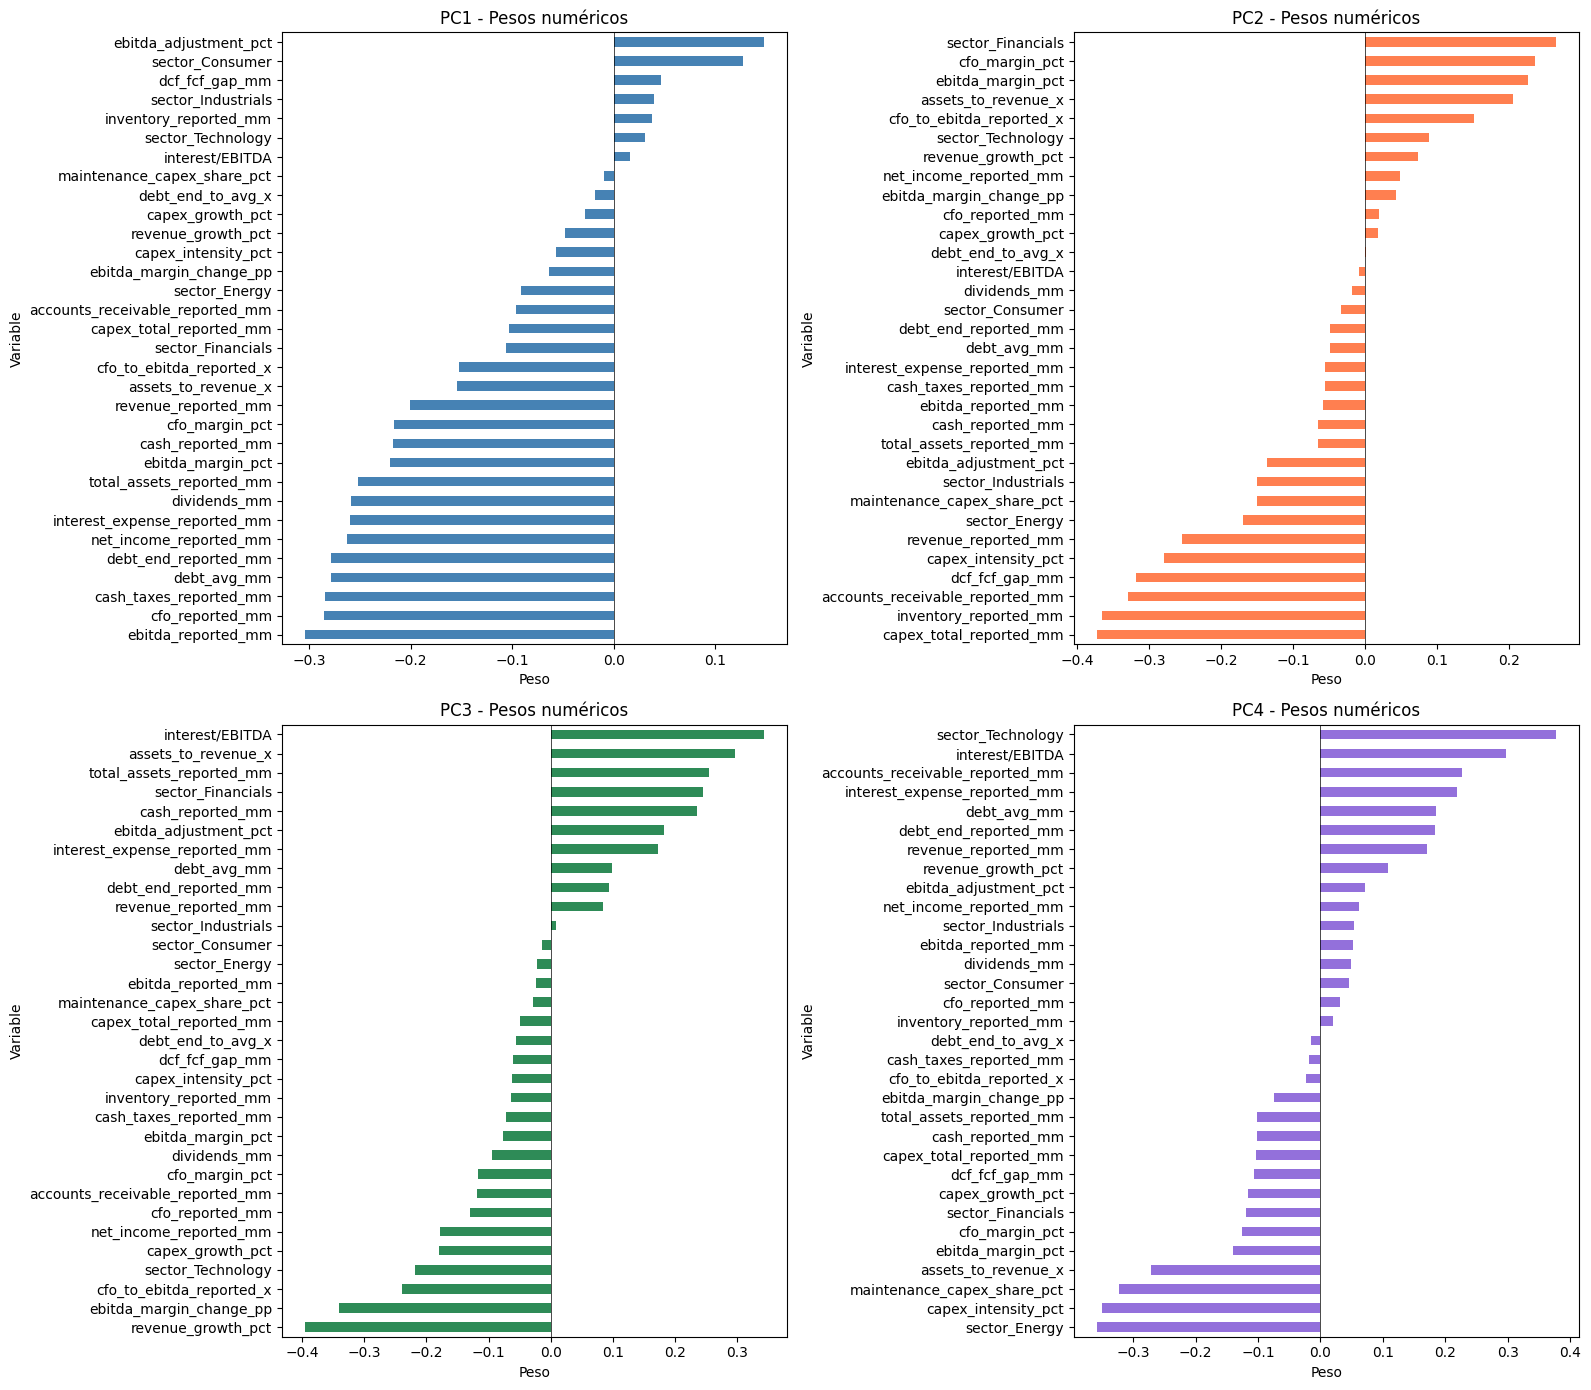

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

colores = ['steelblue', 'coral', 'seagreen', 'mediumpurple']

for i in range(4):
    pc = f'PC{i+1}'
    pesos_pc = pesos[pc].sort_values()

    pesos_pc.plot(
        kind='barh',
        ax=axes[i],
        color=colores[i]
    )

    axes[i].set_title(f'{pc} - Pesos numéricos')
    axes[i].set_xlabel('Peso')
    axes[i].set_ylabel('Variable')
    axes[i].axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

## Clusters

In [29]:
# Usamos los componentes que alcanzan el 95% varianza
cluster_components = [
    f"PC{i}" for i in range(1, k_95 + 1)
]
scaled_data = famd_df[cluster_components].copy()
print(f"Componentes usados para clustering: {len(cluster_components)}")

Componentes usados para clustering: 14


,Inercia,Silhouette,Calinski-Harabasz,Davies-Bouldin,Cluster mas chico,Cluster mas grande
K,,,,,,
2,23041.728,0.191,285.689,1.799,443,557
3,19147.245,0.219,273.119,1.578,191,425
4,17220.493,0.188,239.395,1.708,188,320
5,15948.708,0.182,213.505,1.725,167,242
6,14936.668,0.188,195.664,1.775,91,212
7,14132.997,0.185,181.563,1.644,41,209
8,13430.607,0.193,171.010,1.617,53,184


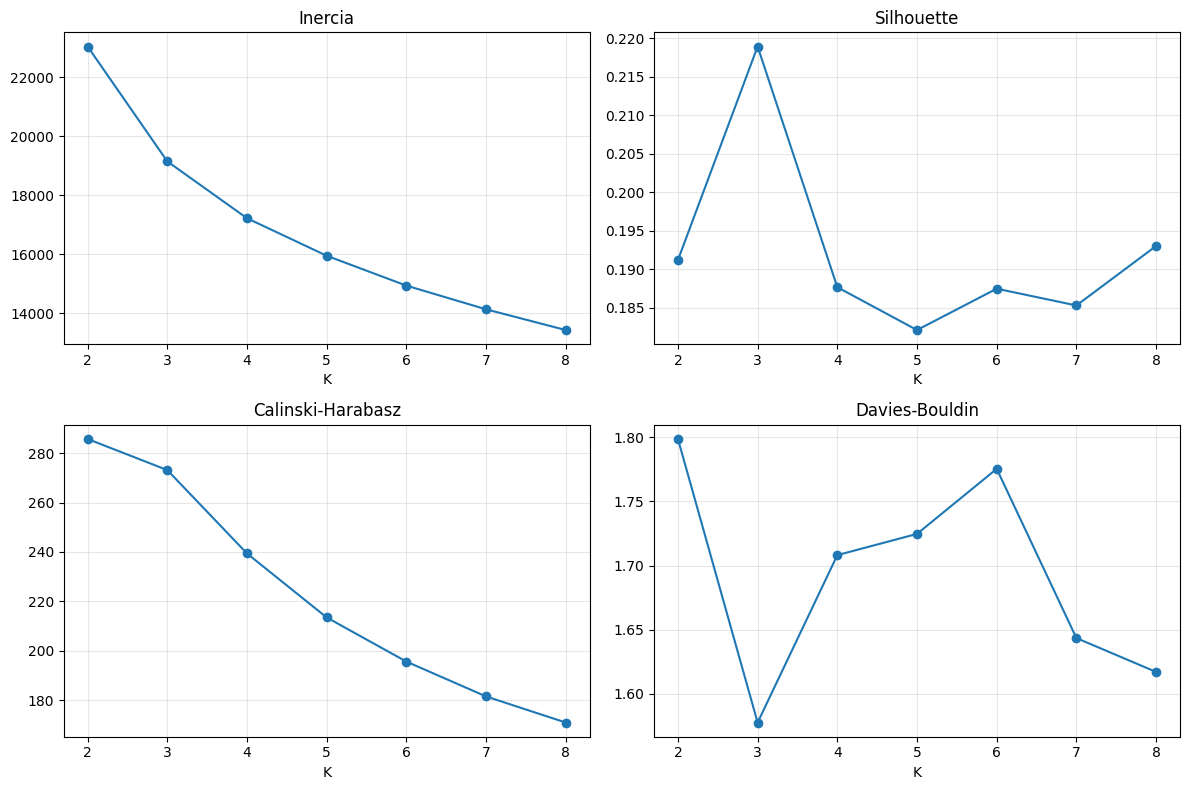

In [37]:
# Probamos varias cantidades de clusters
valores_k = range(2, 9)
resultados_k = []
labels_por_k = {}
modelos_por_k = {}

for k in valores_k:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = modelo.fit_predict(scaled_data)
    labels_por_k[k] = labels
    modelos_por_k[k] = modelo

    tamanos = pd.Series(labels).value_counts()

    resultados_k.append({
        'K': k,
        'Inercia': modelo.inertia_,
        'Silhouette': silhouette_score(scaled_data, labels),
        'Calinski-Harabasz': calinski_harabasz_score(scaled_data, labels),
        'Davies-Bouldin': davies_bouldin_score(scaled_data, labels),
        'Cluster mas chico': tamanos.min(),
        'Cluster mas grande': tamanos.max()
    })

metricas_k = pd.DataFrame(resultados_k).set_index('K')
display(metricas_k.round(3))

# Graficos de las metricas
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

metricas_k['Inercia'].plot(marker='o', ax=axes[0, 0])
axes[0, 0].set_title('Inercia')

metricas_k['Silhouette'].plot(marker='o', ax=axes[0, 1])
axes[0, 1].set_title('Silhouette')

metricas_k['Calinski-Harabasz'].plot(marker='o', ax=axes[1, 0])
axes[1, 0].set_title('Calinski-Harabasz')

metricas_k['Davies-Bouldin'].plot(marker='o', ax=axes[1, 1])
axes[1, 1].set_title('Davies-Bouldin')

for ax in axes.flat:
    ax.set_xlabel('K')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()



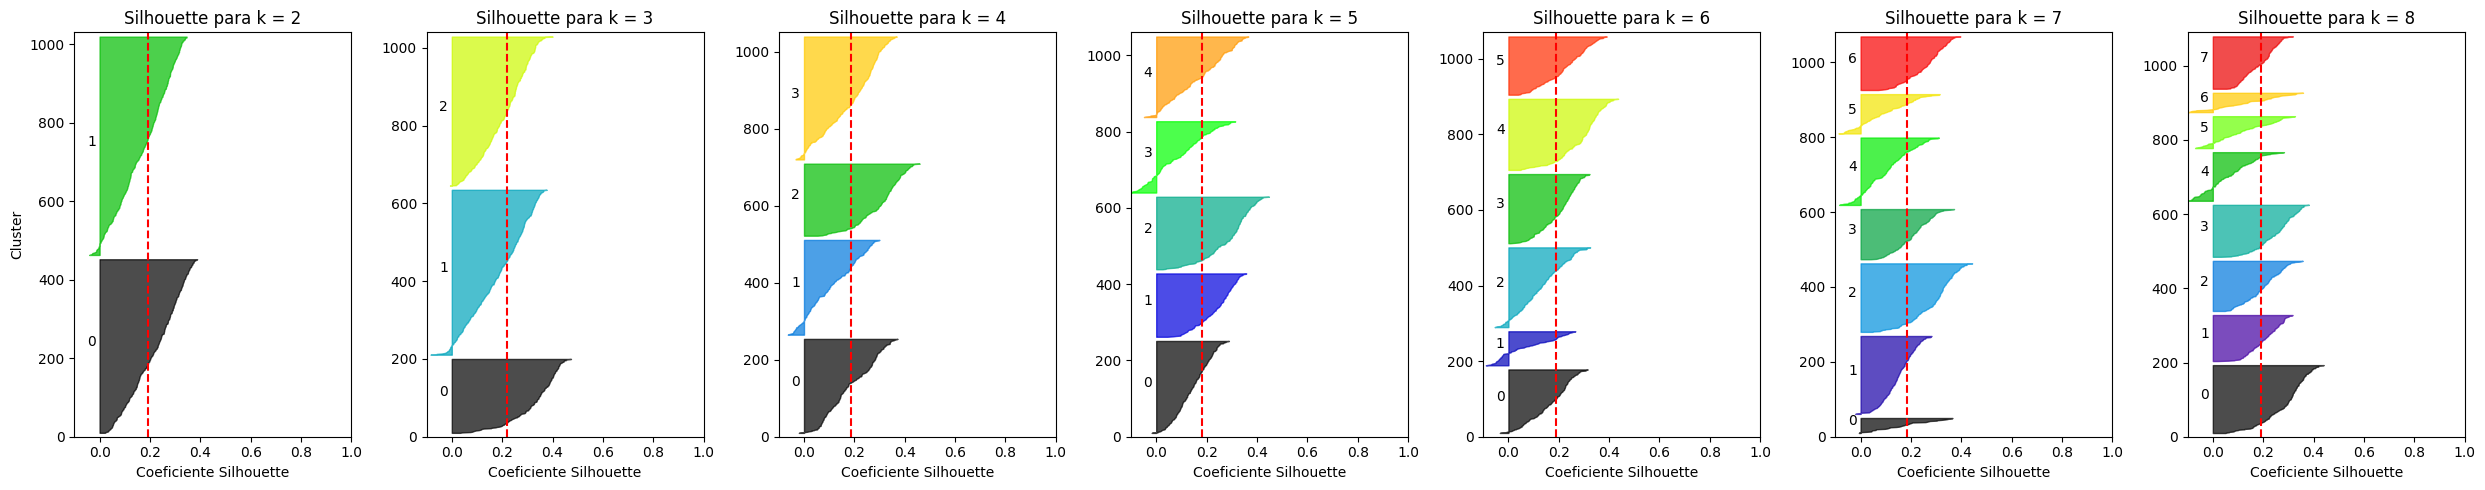

In [38]:
# Grafico Silhouette para cada valor de K
fig, axes = plt.subplots(1, len(valores_k), figsize=(25, 5), sharey=False)

for i, k in enumerate(valores_k):
    ax = axes[i]

    labels = labels_por_k[k]
    sil_vals = silhouette_samples(scaled_data, labels)
    sil_avg = silhouette_score(scaled_data, labels)

    y_lower = 10
    for j in range(k):
        sil_cluster = sil_vals[labels == j]
        sil_cluster.sort()
        tamanio = sil_cluster.shape[0]
        y_upper = y_lower + tamanio
        color = plt.cm.nipy_spectral(float(j) / k)

        ax.fill_betweenx(np.arange(y_lower, y_upper),
                         0, sil_cluster,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * tamanio, str(j))
        y_lower = y_upper + 10

    ax.set_title(f'Silhouette para k = {k}')
    ax.axvline(x=sil_avg, color='red', linestyle='--')
    ax.set_xlabel('Coeficiente Silhouette')
    if i == 0:
        ax.set_ylabel('Cluster')
    ax.set_xlim([-0.1, 1])
    ax.set_ylim([0, len(scaled_data) + (k + 1) * 10])

plt.tight_layout()
plt.show()


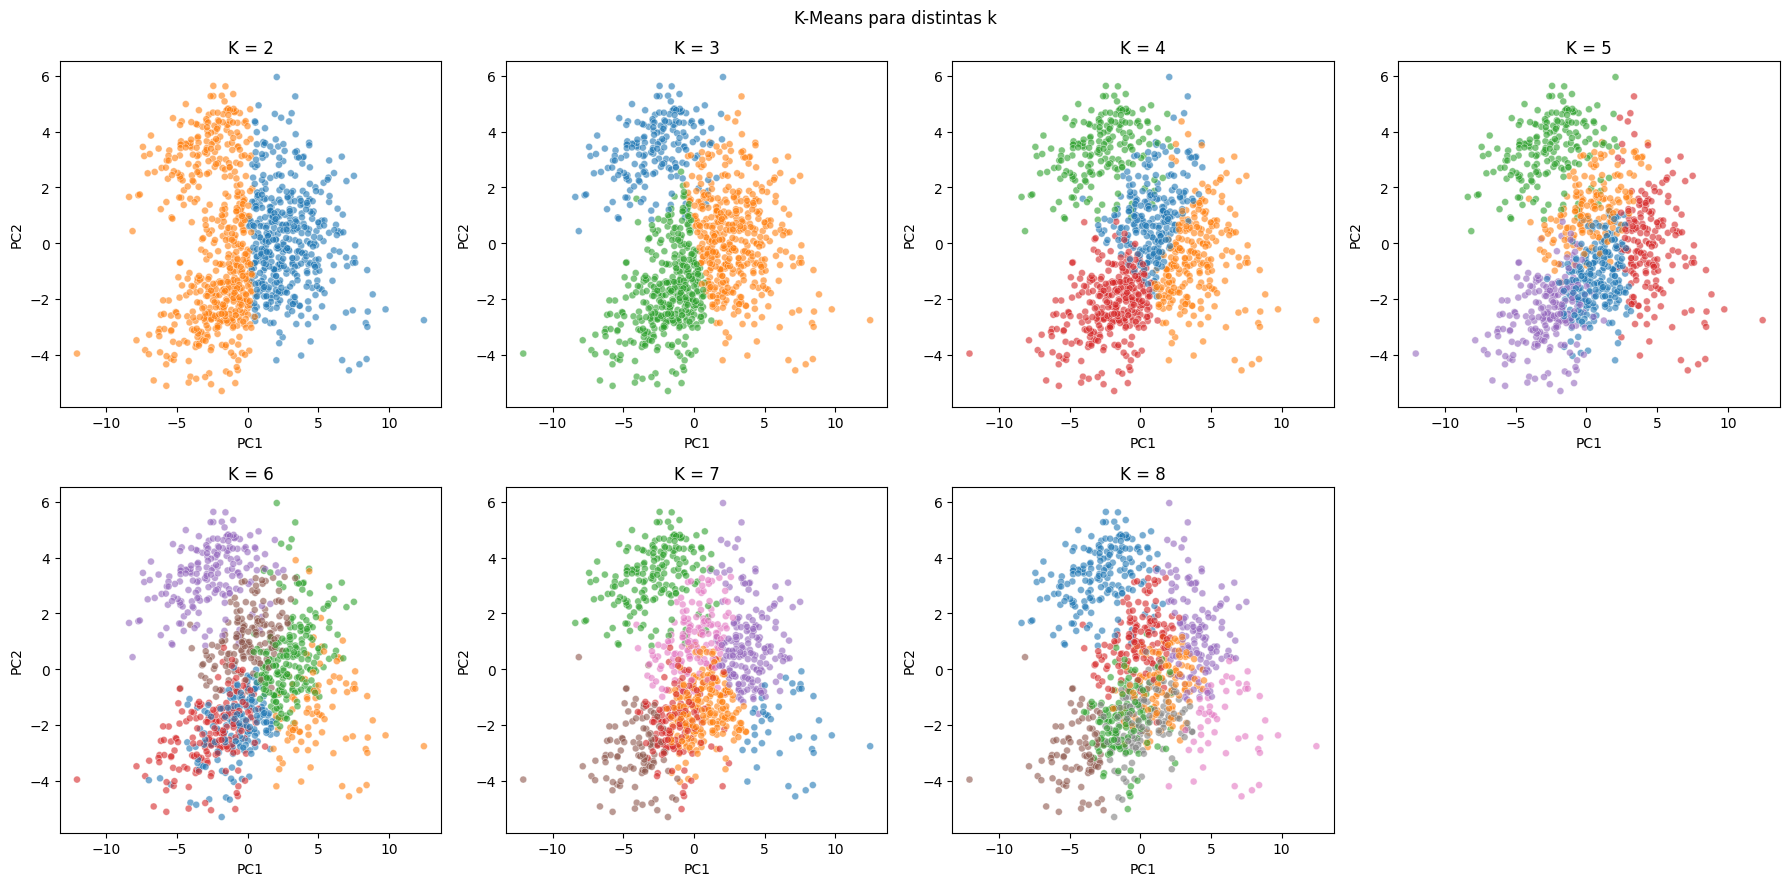

In [39]:
# Vista de los clusters en los primeros dos componentes
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for ax, k in zip(axes, valores_k):
    sns.scatterplot(
        x=scaled_data['PC1'],
        y=scaled_data['PC2'],
        hue=labels_por_k[k],
        palette='tab10',
        alpha=0.6,

        s=25,
        legend=False,
        ax=ax
    )
    ax.set_title(f'K = {k}')

axes[-1].axis('off')
plt.suptitle('K-Means para distintas k')
plt.tight_layout()
plt.show()

In [40]:
# Elegimos K despues de comparar la tabla y los graficos anteriores
K = 3

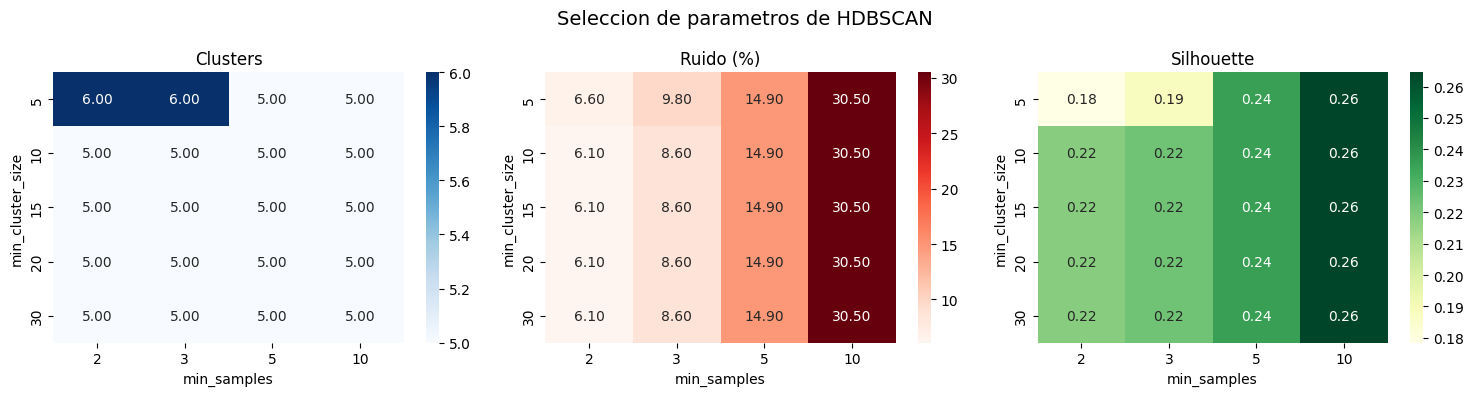

In [41]:
## Vemos las matrices de los dos parametros de HDBSCAN
resultados_hdbscan = []

for min_cluster_size in [5, 10, 15, 20, 30]:
    for min_samples in [2, 3, 5, 10]:

        labels = HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
              copy=True
        ).fit_predict(scaled_data)

        validos = labels != -1
        n_clusters = len(np.unique(labels[validos]))
        ruido = 100 * (1 - validos.mean())

        silhouette = (
            silhouette_score(scaled_data.loc[validos], labels[validos])
            if n_clusters >= 2 else np.nan
        )

        resultados_hdbscan.append({
            "min_cluster_size": min_cluster_size,
            "min_samples": min_samples,
            "Clusters": n_clusters,
            "Ruido (%)": ruido,
            "Silhouette": silhouette
        })

resultados_hdbscan = pd.DataFrame(resultados_hdbscan)


metricas = ["Clusters", "Ruido (%)", "Silhouette"]
paletas = ["Blues", "Reds", "YlGn"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for metrica, paleta, ax in zip(metricas, paletas, axes):
    matriz = resultados_hdbscan.pivot(
        index="min_cluster_size",
        columns="min_samples",
        values=metrica
    )
    sns.heatmap(matriz, annot=True, fmt=".2f", cmap=paleta, ax=ax)
    ax.set_title(metrica)

plt.suptitle("Seleccion de parametros de HDBSCAN", fontsize=14)
plt.tight_layout()
plt.show()

In [42]:

modelos = {
    "K-Means": KMeans(n_clusters=K, random_state=42, n_init=10),
    "HDBSCAN": HDBSCAN(min_cluster_size=10, min_samples=3, copy=True),
    #"Jerárquico": AgglomerativeClustering(n_clusters=K, linkage="ward"),
    "GMM - euclidiano": GaussianMixture(
        n_components=K, covariance_type="spherical", random_state=42, n_init=10
    )
}

labels_por_modelo = {}
resultados = []

for nombre, modelo in modelos.items():
    labels = modelo.fit_predict(scaled_data)
    labels_por_modelo[nombre] = labels

    # HDBSCAN marca el ruido con -1. No lo usamos para calcular las métricas.
    puntos_validos = labels != -1
    X_validos = scaled_data.loc[puntos_validos]
    labels_validos = labels[puntos_validos]
    n_clusters = len(np.unique(labels_validos))

    if n_clusters >= 2:
        silhouette = silhouette_score(X_validos, labels_validos)
        calinski = calinski_harabasz_score(X_validos, labels_validos)
        davies = davies_bouldin_score(X_validos, labels_validos)
    else:
        silhouette, calinski, davies = np.nan, np.nan, np.nan

    resultados.append({
        "Método": nombre,
        "N° clusters": n_clusters,
        "Ruido (%)": 100 * (1 - puntos_validos.mean()),
        "Silhouette ↑": silhouette,
        "Calinski-Harabasz ↑": calinski,
        "Davies-Bouldin ↓": davies
    })

metricas_clusters = pd.DataFrame(resultados).set_index("Método")
print("Nota: Silhouette, Calinski-Harabasz y Davies-Bouldin se calculan con"
      " geometría euclidiana para comparar todas las particiones bajo el mismo criterio.")
metricas_clusters.round(3)

Nota: Silhouette, Calinski-Harabasz y Davies-Bouldin se calculan con geometría euclidiana para comparar todas las particiones bajo el mismo criterio.


,N° clusters,Ruido (%),Silhouette ↑,Calinski-Harabasz ↑,Davies-Bouldin ↓
Método,,,,,
K-Means,3,0.0,0.219,273.119,1.578
HDBSCAN,5,8.6,0.223,194.309,1.620
GMM - euclidiano,3,0.0,0.219,271.122,1.553


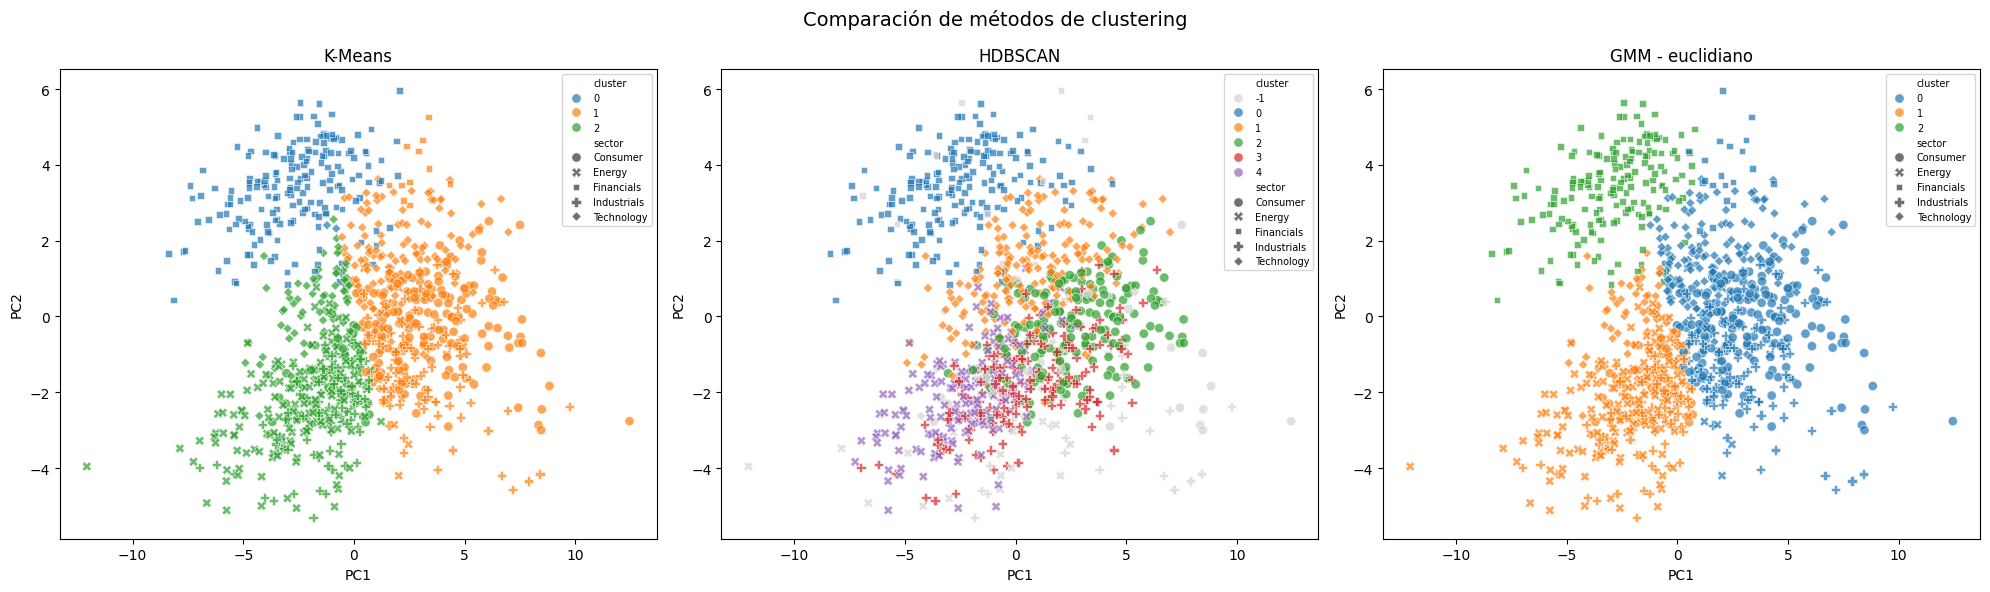

In [43]:
n_modelos = len(labels_por_modelo)
n_cols = 3
n_rows = int(np.ceil(n_modelos / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6 * n_rows))
axes = np.atleast_1d(axes).ravel()
colores = sns.color_palette("tab10", 10)

for ax, (nombre, labels) in zip(axes, labels_por_modelo.items()):
    grupos = np.unique(labels)
    paleta = {
        grupo: ("lightgray" if grupo == -1 else colores[grupo % 10])
        for grupo in grupos
    }

    datos_plot = scaled_data[["PC1", "PC2"]].copy()
    datos_plot["cluster"] = labels
    datos_plot["sector"] = sector.values

    sns.scatterplot(
        data=datos_plot,
        x="PC1",
        y="PC2",
        hue="cluster",       # color = cluster
        style="sector",      # forma = sector
        palette=paleta,
        alpha=0.7,
        s=45,
        ax=ax
    )
    ax.set_title(nombre)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(fontsize=7, title_fontsize=8)

for ax in axes[n_modelos:]:
    ax.axis("off")

plt.suptitle("Comparación de métodos de clustering", fontsize=14)
plt.tight_layout()
plt.show()

cantidad de empresas por cluster


,Empresas
0,191
1,425
2,384


porcentaje de sectores


sector,Consumer,Energy,Financials,Industrials,Technology
cluster,,,,,
0,0.0,0.0,99.0,0.0,1.0
1,40.0,4.0,2.6,23.3,30.1
2,7.8,47.7,0.0,26.3,18.2


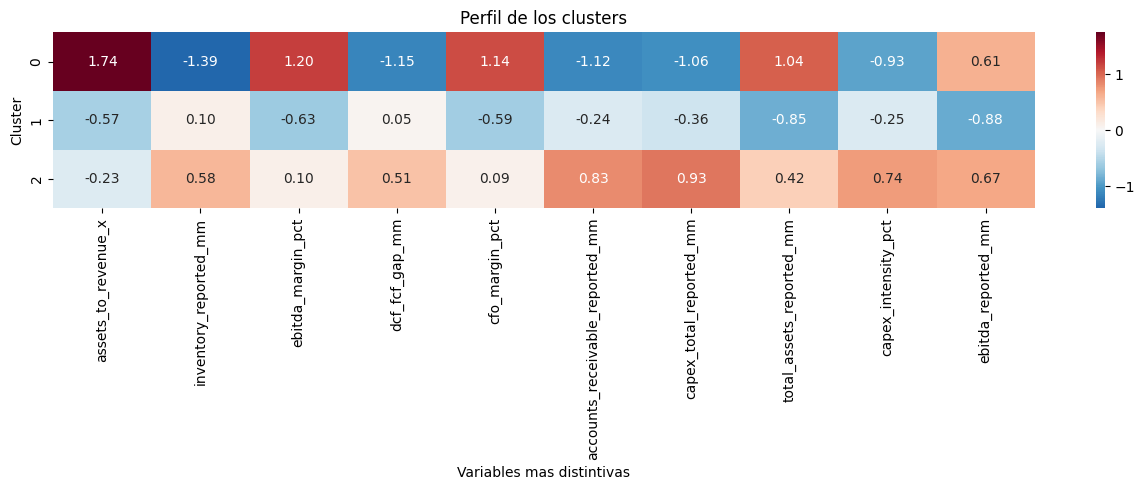

In [44]:


labels = labels_por_k[K]

perfiles_k = numeric_scaled_df.copy()

perfiles_k['cluster'] = labels
perfil_promedio_k = perfiles_k.groupby('cluster').mean()

tamanos_k = pd.Series(labels).value_counts().sort_index()
sectores_k = pd.crosstab(
    pd.Series(labels, name='cluster'),
    sector.reset_index(drop=True),
    normalize='index'
).mul(100).round(1)

print(f'cantidad de empresas por cluster')
display(tamanos_k.to_frame('Empresas'))
print(f'porcentaje de sectores')
display(sectores_k)

# Mostramos solo las 10 variables que mas separan estos clusters
variables_clave = perfil_promedio_k.abs().max().nlargest(10).index

plt.figure(figsize=(13, 5 ))
sns.heatmap(
    perfil_promedio_k[variables_clave],
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt='.2f'
)
plt.title(f'Perfil de los clusters')
plt.xlabel('Variables mas distintivas')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

In [45]:
def graficar_perfiles(features, titulo):
    plt.figure(figsize=(13, 5))

    ax = sns.heatmap(
        perfil_promedio_k[features],
        cmap="RdBu_r",
        center=0,
        annot=True,
        fmt=".2f"
    )

    plt.title(titulo)
    plt.xlabel("Variables")
    plt.ylabel("Cluster")
    plt.tight_layout()
    plt.show()

    return ax



### Resultados y generación de caja

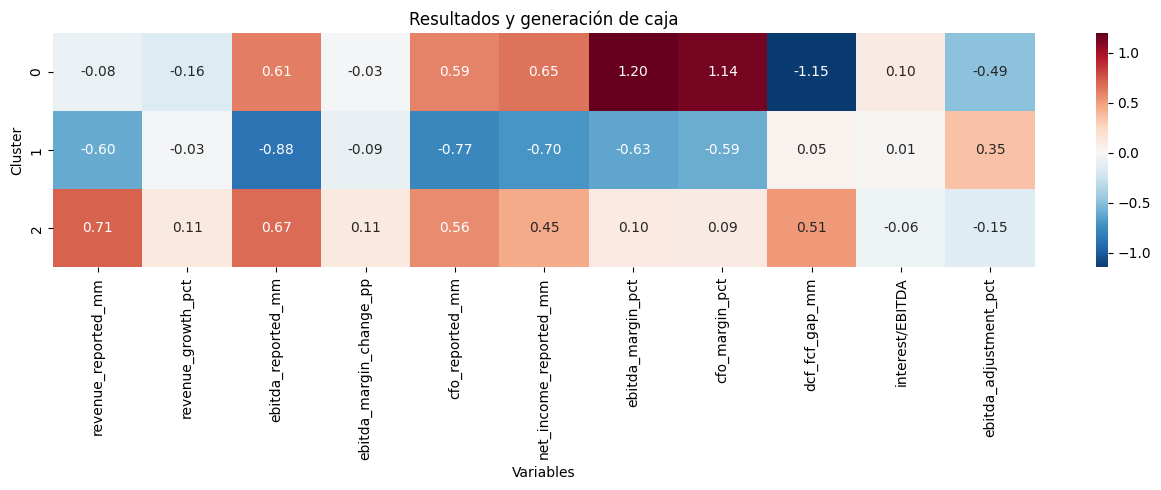

<Axes: title={'center': 'Resultados y generación de caja'}, xlabel='Variables', ylabel='Cluster'>

In [46]:
features_elegidas = [
    "revenue_reported_mm",
    "revenue_growth_pct",
    "ebitda_reported_mm",
    "ebitda_margin_change_pp",
    "cfo_reported_mm",
    "net_income_reported_mm",
    "ebitda_margin_pct",
    "cfo_margin_pct",
    "dcf_fcf_gap_mm",
        "interest/EBITDA",
    "ebitda_adjustment_pct",
]

graficar_perfiles(
    features_elegidas,
    "Resultados y generación de caja"
)


### Deuda y taxes

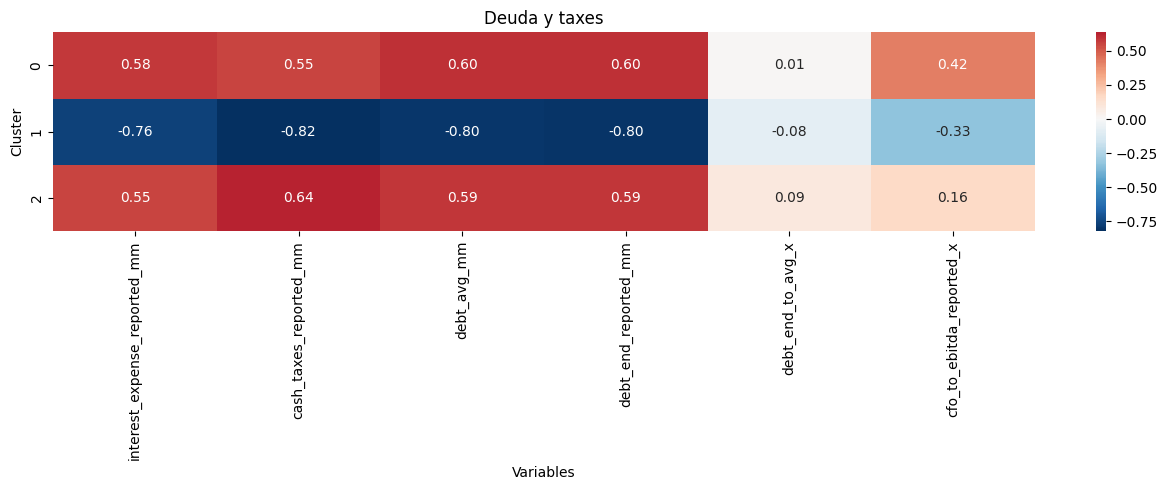

<Axes: title={'center': 'Deuda y taxes'}, xlabel='Variables', ylabel='Cluster'>

In [37]:
features_elegidas = [
    "interest_expense_reported_mm",
    "cash_taxes_reported_mm",
    "debt_avg_mm",
    "debt_end_reported_mm",
    "debt_end_to_avg_x",
    "cfo_to_ebitda_reported_x",
]

graficar_perfiles(
    features_elegidas,
    "Deuda y taxes"
)


### Capex

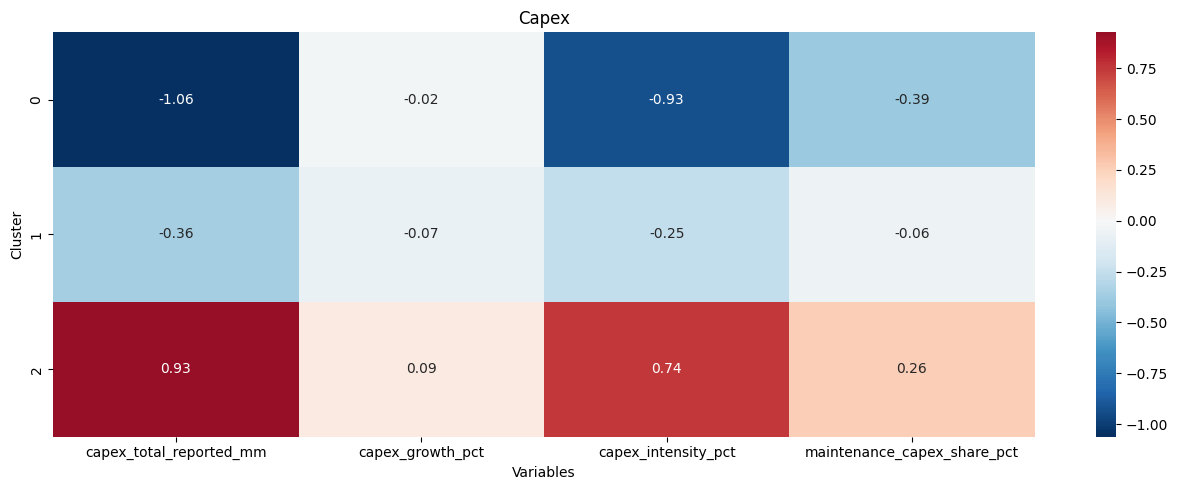

<Axes: title={'center': 'Capex'}, xlabel='Variables', ylabel='Cluster'>

In [38]:
features_elegidas = [
    "capex_total_reported_mm",
    "capex_growth_pct",
    "capex_intensity_pct",
    "maintenance_capex_share_pct",
]

graficar_perfiles(
    features_elegidas,
    "Capex"
)

### Activos

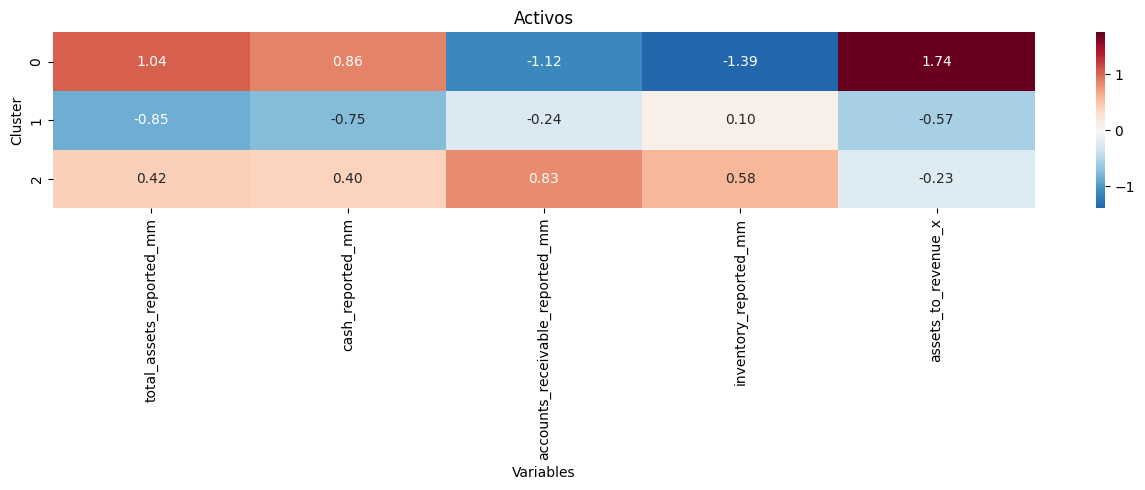

<Axes: title={'center': 'Activos'}, xlabel='Variables', ylabel='Cluster'>

In [39]:
features_elegidas = [
    "total_assets_reported_mm",
    "cash_reported_mm",
    "accounts_receivable_reported_mm",
    "inventory_reported_mm",
    "assets_to_revenue_x",
]

graficar_perfiles(
    features_elegidas,
    "Activos"
)

## Evaluación final con la target

La target no se usa para crear los componentes, formar los clusters ni elegir K. Se consulta al final para evaluar si las empresas manipuladas reciben puntajes de rareza altos.

Empresas manipuladas: 120 de 1000


,AUC distancia,Precision top 10%,Recall top 10%,Manipuladas detectadas
K,,,,
2,0.699,0.27,0.225,27
3,0.633,0.27,0.225,27
4,0.665,0.32,0.267,32
5,0.676,0.28,0.233,28
6,0.690,0.35,0.292,35
7,0.694,0.35,0.292,35
8,0.711,0.34,0.283,34


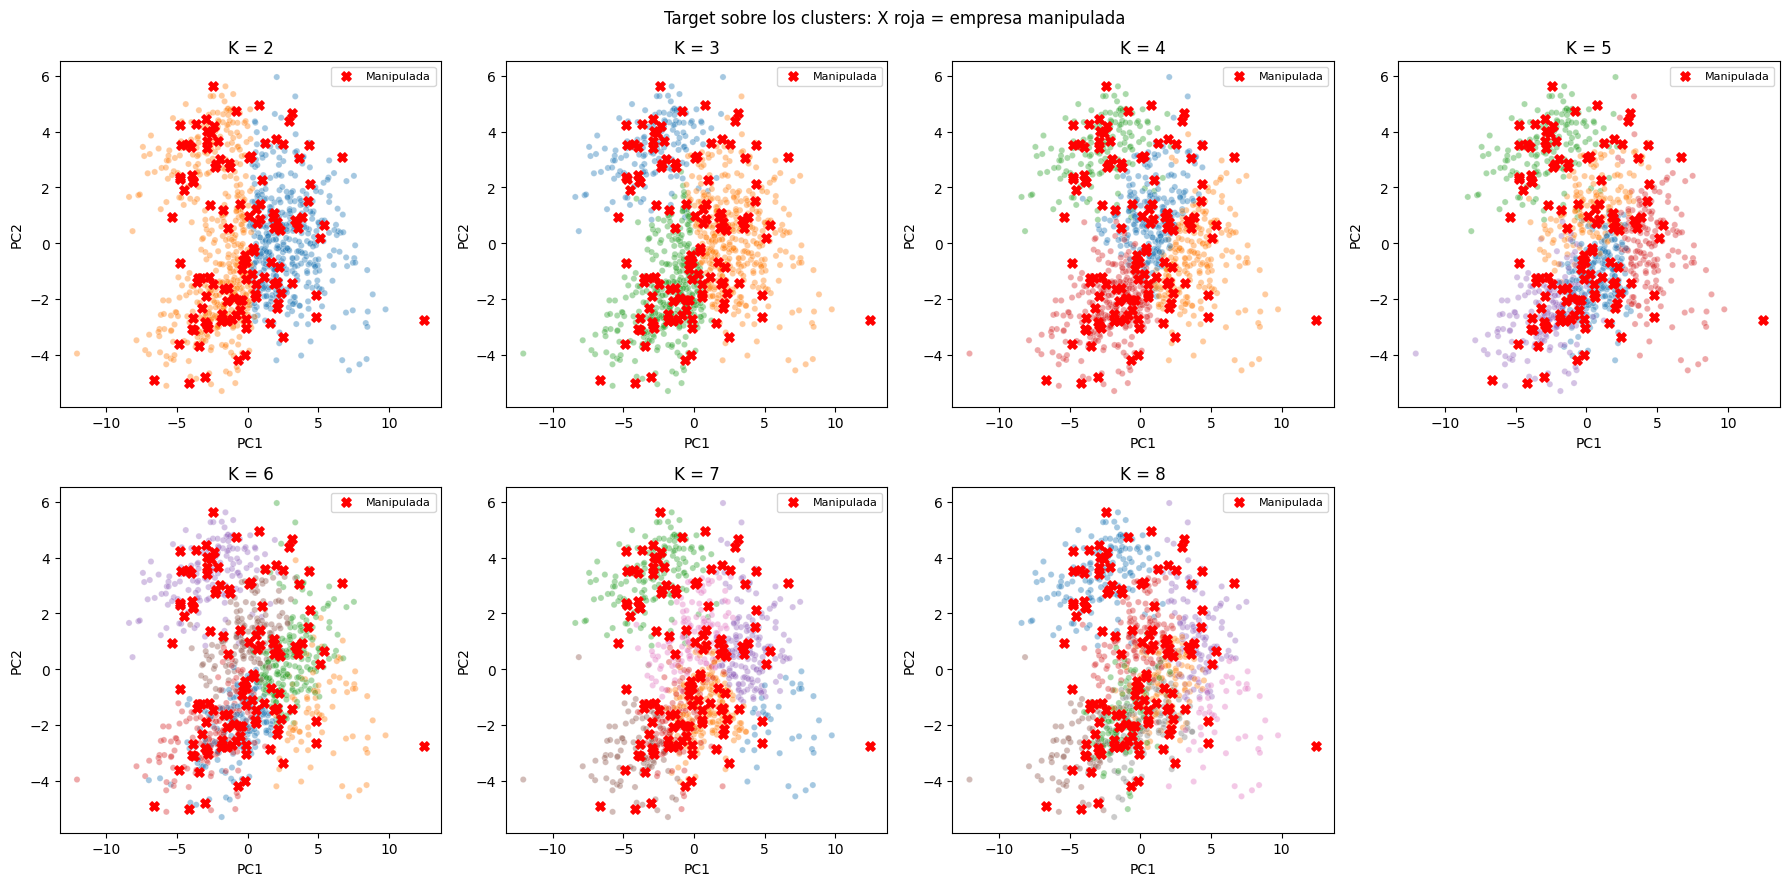

In [31]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score

# Leemos las etiquetas solamente para la evaluacion final
etiquetas_df = pd.read_excel(
    excel_path,
    sheet_name='Etiquetas - usar al final',
    header=2
)

target = df[['firm_id']].merge(
    etiquetas_df[['firm_id', 'is_manipulated']],
    on='firm_id',
    how='left'
)['is_manipulated'].astype(int)

print(f'Empresas manipuladas: {target.sum()} de {len(target)}')

# Consideramos alertas al 10% de empresas mas alejadas de su centro
resultados_target = []
n_alertas = int(len(target) * 0.10)

for k in valores_k:
    modelo = modelos_por_k[k]
    labels = labels_por_k[k]

    centros_asignados = modelo.cluster_centers_[labels]
    distancias = np.linalg.norm(scaled_data.values - centros_asignados, axis=1)

    indices_alerta = np.argsort(distancias)[-n_alertas:]
    alertas = np.zeros(len(target), dtype=int)
    alertas[indices_alerta] = 1

    resultados_target.append({
        'K': k,
        'AUC distancia': roc_auc_score(target, distancias),
        'Precision top 10%': precision_score(target, alertas),
        'Recall top 10%': recall_score(target, alertas),
        'Manipuladas detectadas': ((target == 1) & (alertas == 1)).sum()
    })

evaluacion_target_k = pd.DataFrame(resultados_target).set_index('K')
display(evaluacion_target_k.round(3))

# Las X rojas muestran donde esta la target en cada solucion
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
manipuladas = target == 1

for ax, k in zip(axes, valores_k):
    sns.scatterplot(
        x=scaled_data['PC1'],
        y=scaled_data['PC2'],
        hue=labels_por_k[k],
        palette='tab10',
        alpha=0.4,
        s=20,
        legend=False,
        ax=ax
    )
    ax.scatter(
        scaled_data.loc[manipuladas, 'PC1'],
        scaled_data.loc[manipuladas, 'PC2'],
        color='red',
        marker='X',
        s=45,
        label='Manipulada'
    )
    ax.set_title(f'K = {k}')
    ax.legend(fontsize=8)

axes[-1].axis('off')
plt.suptitle('Target sobre los clusters: X roja = empresa manipulada')
plt.tight_layout()
plt.show()